In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_excel('rotation_schedule_data_2023-25deid.xlsx')
df2=pd.read_excel('Vizient Database Termination Data de-identified.xlsx')

In [47]:
status_map={
    'Archived (Completed)': 'Completed',
    'Archived (Withdrawn)': 'Withdrawn',
    'Archived (Denied)': 'Denied'
}
df['Cleaned Status']=df['Status'].replace(status_map)

In [48]:
df['Start Date']=pd.to_datetime(df['Start Date'])
df['Year']=df['Start Date'].dt.year
df['Cohort']=df['Start Date'].dt.month.apply(lambda x: 'Spring' if x<=4 else 'Summer' if x<=8 else 'Fall')+" "+df['Year'].astype(str)

In [ ]:
df_cohorts_completed=df[(df['Experience']=='Cohort Rotation')&(df['Cleaned Status']=='Completed')].copy()
school_cohorts=df_cohorts_completed['Schools'].value_counts()
schools=school_cohorts[school_cohorts>=2].index
print(df.loc[~df['Schools'].isin(schools),'Schools'].unique())
print(df.loc[df['Schools'].isin(schools),'Schools'].unique())
df_accurate_sample=df_cohorts_completed[df_cohorts_completed['Schools'].isin(schools)]

In [76]:
df_accurate_sample['Students']=pd.to_numeric(df_accurate_sample['Students'],'coerce')
df_accurate_sample['Students']=df_accurate_sample['Students'].astype('Int64',errors='ignore')
df2['Deid_Names']=df2['Deid_Names'].astype('Int64')

In [ ]:
df3=df_accurate_sample.merge(df2, 'inner', left_on='Students', right_on='Deid_Names')
print(df3)
df['Students']=pd.to_numeric(df['Students'],'coerce')
df['Students']=df['Students'].astype('Int64',errors='ignore')
df4=df.merge(df2, 'inner', left_on='Students', right_on='Deid_Names')
print(df4)

In [111]:
viz_nclex=pd.read_csv('merged_viz_nclex_gpa.csv')

# Yolanda's code
df.columns = df.columns.str.strip()
viz_nclex.columns = viz_nclex.columns.str.strip()
# Create a mapping from Rotation school names -> Vizient standardized names
school_mapping = {
    'chamberlain college of nursing - georgia': None,  # no match in Vizient
    'chamberlain college of nursing - atlanta': None,  # no match in Vizient
    'Georgia Baptist College of Nursing of Mercer University - Undergraduate Nursing': 'Mercer University',
    'Georgia Baptist College of Nursing of Mercer University - Undergraduate Nursing - Atlanta': 'Mercer University',
    'Kennesaw State University - Nursing': 'Kennesaw State University',
    'Emory University - SON Pre-licensure': 'Emory University',
    'Georgia State University - Perimeter College': 'Georgia State University',
    'Georgia State University - SON - Undergraduate': 'Georgia State University',
    'University of North Georgia - Nursing': 'University Of North Georgia',
    'Georgia Gwinnett College': 'Georgia Gwinnett College',
    'South College - Atlanta Campus - Nursing': 'South College Atlanta'
}
# Apply the mapping
df['School_Cleaned'] = df['Schools'].map(school_mapping)
# Optional: if you want to keep original names where no match exists
df['School_Cleaned'] = df['School_Cleaned'].fillna(df['Schools'])
# Check the result
print(df[['Schools', 'School_Cleaned']].head(40))

hours_retention=df.merge(viz_nclex, 'inner', left_on='School_Cleaned', right_on='School')
hours_retention.to_csv('hours_retention.csv', index=False)

                                              Schools  \
0            Chamberlain College of Nursing - Georgia   
1            Chamberlain College of Nursing - Georgia   
2            Chamberlain College of Nursing - Georgia   
3            Chamberlain College of Nursing - Georgia   
4            Chamberlain College of Nursing - Georgia   
5            Chamberlain College of Nursing - Georgia   
6            Chamberlain College of Nursing - Georgia   
7            Chamberlain College of Nursing - Georgia   
8            Chamberlain College of Nursing - Georgia   
9            Chamberlain College of Nursing - Georgia   
10           Chamberlain College of Nursing - Georgia   
11           Chamberlain College of Nursing - Georgia   
12           Chamberlain College of Nursing - Georgia   
13           Chamberlain College of Nursing - Georgia   
14           Chamberlain College of Nursing - Georgia   
15           Chamberlain College of Nursing - Georgia   
16           Chamberlain Colleg

Text(0.5, 1.0, 'Total Hours Per Person at Emory Decatur Hospital')

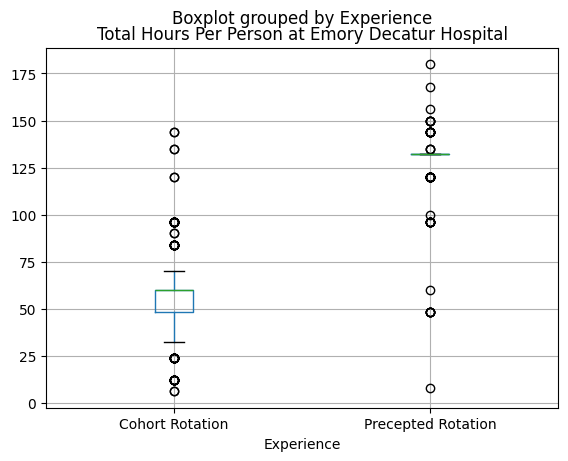

In [50]:
decatur_df=df.loc[df['Sites']=='Emory Decatur Hospital']
decatur_df.boxplot(by='Experience',column='Total Hours per Person').set_title("Total Hours Per Person at Emory Decatur Hospital")

Text(0.5, 1.0, 'Total Hours Per Person at Emory Hillandale Hospital')

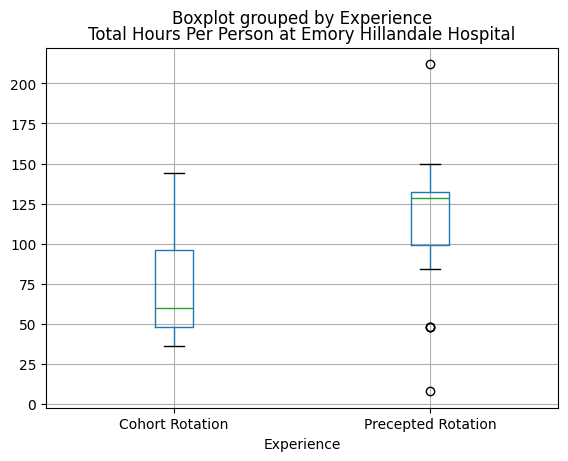

In [51]:
hillandale_df=df.loc[df['Sites']=='Emory Hillandale Hospital']
hillandale_df.boxplot(by='Experience',column='Total Hours per Person').set_title("Total Hours Per Person at Emory Hillandale Hospital")

Text(0.5, 1.0, 'Total Hours Per Person at Emory Johns Creek Hospital')

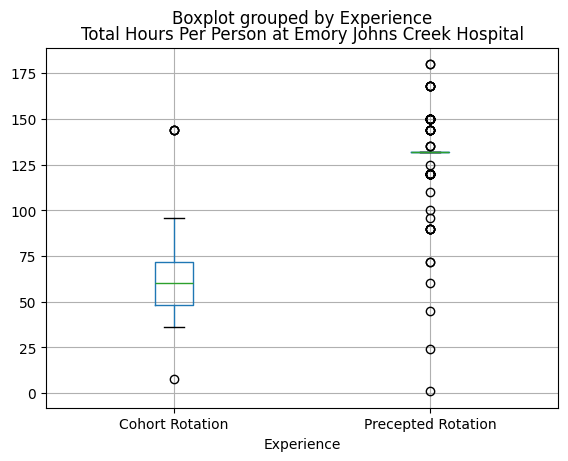

In [52]:
johns_df=df.loc[df['Sites']=='Emory Johns Creek Hospital']
johns_df.boxplot(by='Experience',column='Total Hours per Person').set_title("Total Hours Per Person at Emory Johns Creek Hospital")

Text(0.5, 1.0, 'Total Hours Per Person at Emory Long Term Acute Care Hospital')

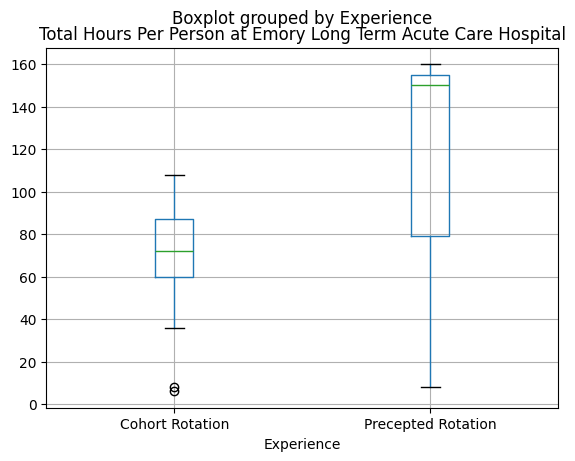

In [53]:
long_df=df.loc[df['Sites']=='Emory Long Term Acute Care Hospital']
long_df.boxplot(by='Experience',column='Total Hours per Person').set_title("Total Hours Per Person at Emory Long Term Acute Care Hospital")

Text(0.5, 1.0, 'Total Hours Per Person at Emory Clinic, Ambulatory Surgery Centers and the Emory Specialty Assocs')

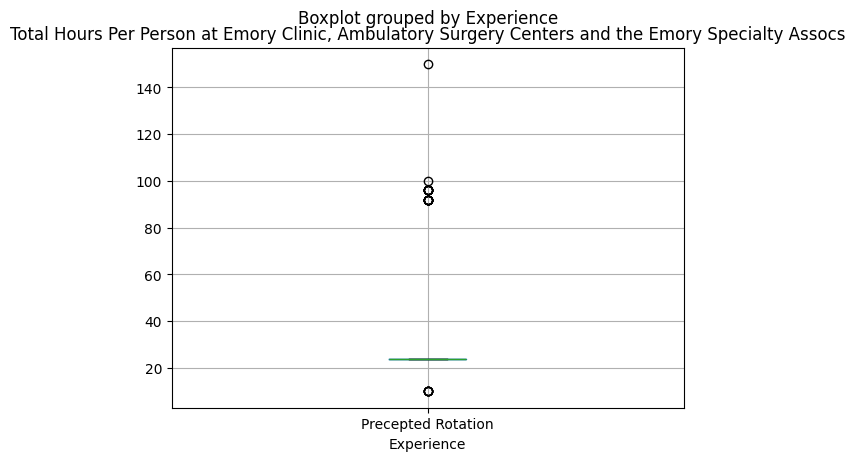

In [55]:
offsite_df=df.loc[df['Sites']=='Emory Offsite locations - The Emory Clinic, Ambulatory Surgery Centers and the Emory Specialty Assocs']
offsite_df.boxplot(by='Experience',column='Total Hours per Person').set_title("Total Hours Per Person at Emory Clinic, Ambulatory Surgery Centers and the Emory Specialty Assocs")

Text(0.5, 1.0, "Total Hours Per Person at Emory Saint Joseph's Hospital")

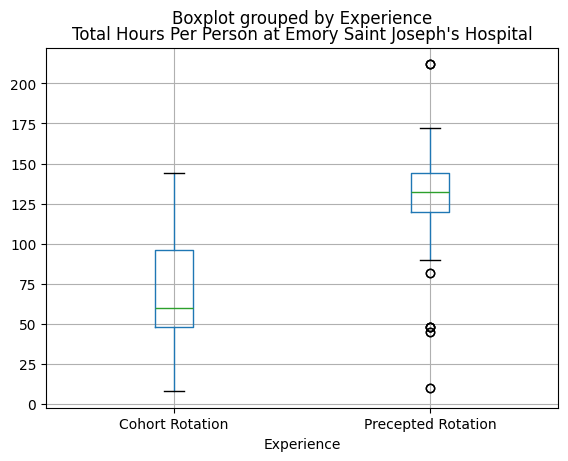

In [56]:
saint_df=df.loc[df['Sites']=="Emory Saint Joseph's Hospital"]
saint_df.boxplot(by='Experience',column='Total Hours per Person').set_title("Total Hours Per Person at Emory Saint Joseph's Hospital")

Text(0.5, 1.0, 'Total Hours Per Person at Emory University Hospital')

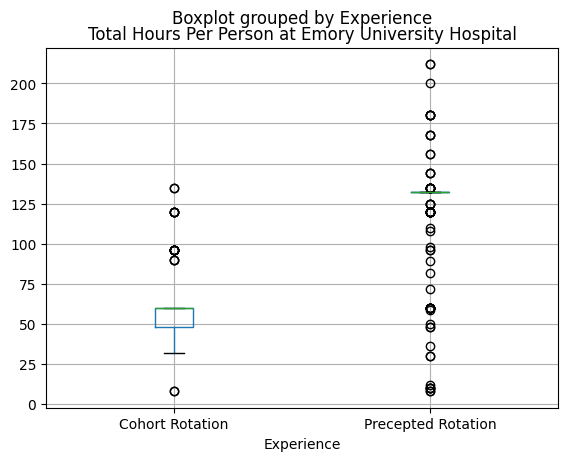

In [57]:
university_df=df.loc[df['Sites']=='Emory University Hospital']
university_df.boxplot(by='Experience',column='Total Hours per Person').set_title("Total Hours Per Person at Emory University Hospital")

Text(0.5, 1.0, 'Total Hours Per Person at Emory University Hospital at Wesley Woods')

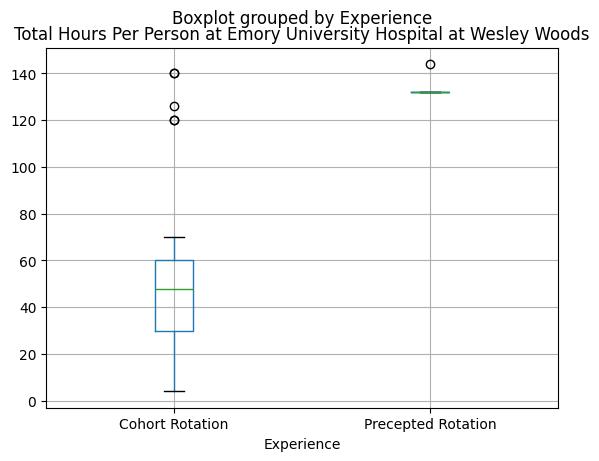

In [64]:
wesley_df=df.loc[df['Sites']=='Emory University Hospital at Wesley Woods']
wesley_df.boxplot(by='Experience',column='Total Hours per Person').set_title("Total Hours Per Person at Emory University Hospital at Wesley Woods")

Text(0.5, 1.0, 'Total Hours Per Person at Emory University Hospital Midtown')

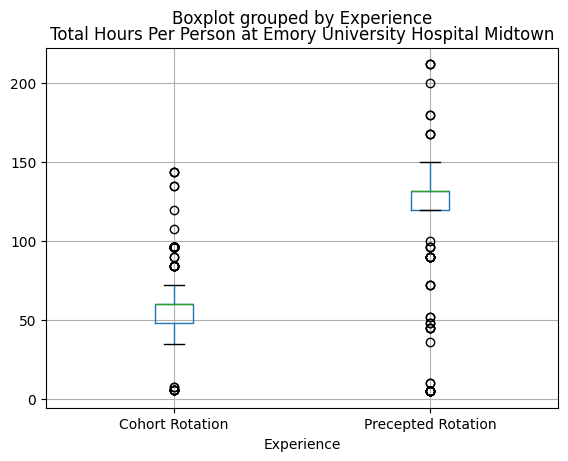

In [59]:
midtown_df=df.loc[df['Sites']=='Emory University Hospital Midtown']
midtown_df.boxplot(by='Experience',column='Total Hours per Person').set_title("Total Hours Per Person at Emory University Hospital Midtown")

Text(0.5, 1.0, 'Total Hours Per Person at Emory University Orthopaedics and Spine Hospital')

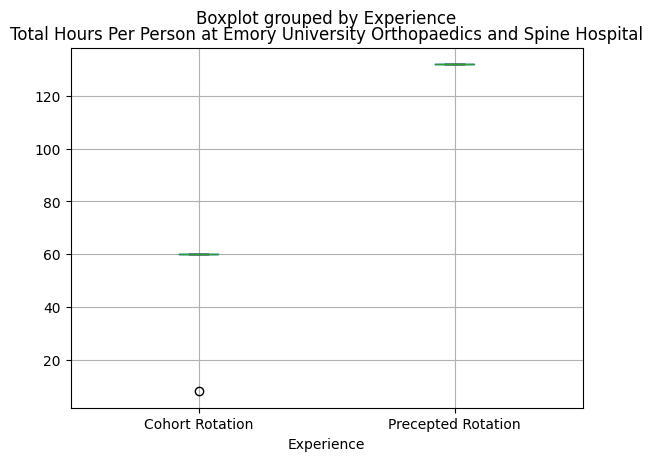

In [60]:
orthopaedics_df=df.loc[df['Sites']=='Emory University Orthopaedics and Spine Hospital']
orthopaedics_df.boxplot(by='Experience',column='Total Hours per Person').set_title("Total Hours Per Person at Emory University Orthopaedics and Spine Hospital")

      Total Hours per Person
364                    212.0
510                    212.0
511                    212.0
1270                   212.0
1557                   212.0
1811                   212.0
1812                   212.0
2798                   212.0
2799                   212.0
     Total Hours per Person
159                   180.0
160                   180.0
161                   180.0
162                   180.0
163                   180.0
203                   180.0
205                   180.0
207                   180.0
208                   180.0
209                     1.0
      Total Hours per Person
120                    140.0
133                    120.0
134                    120.0
158                    140.0
339                    120.0
340                    120.0
341                    120.0
348                    120.0
349                    120.0
350                    120.0
351                    120.0
352                    120.0
353                    12

array([[<Axes: title={'center': 'Total Hours per Person'}>]], dtype=object)

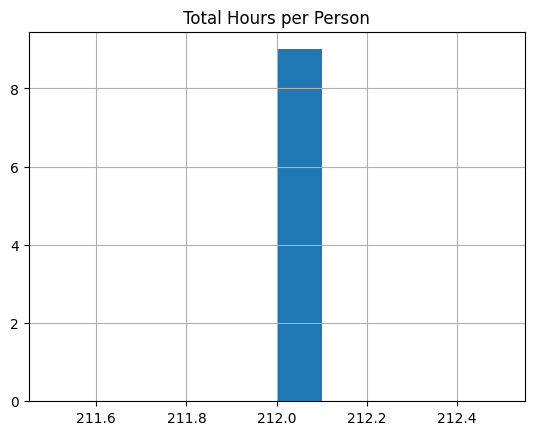

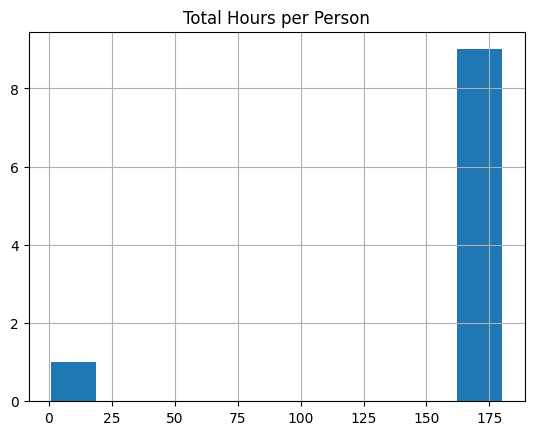

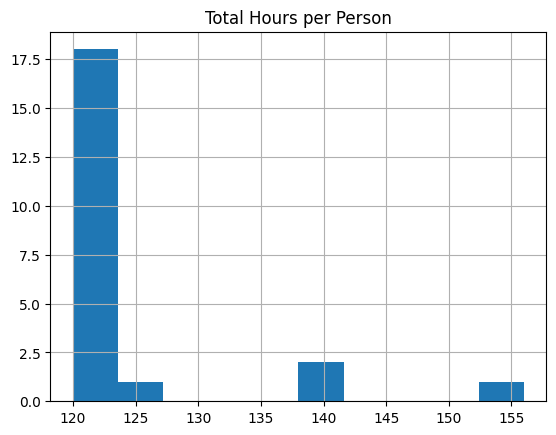

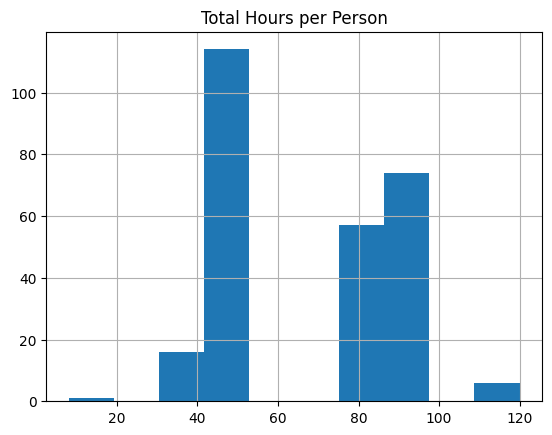

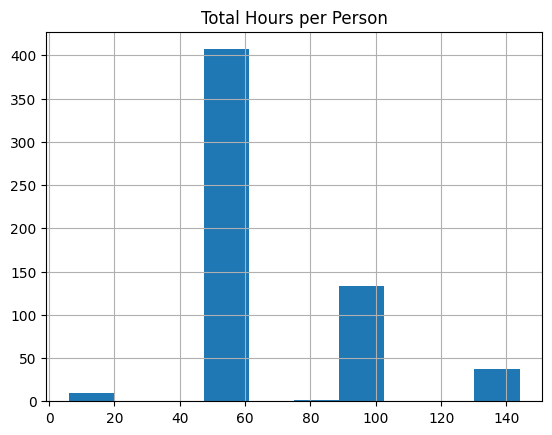

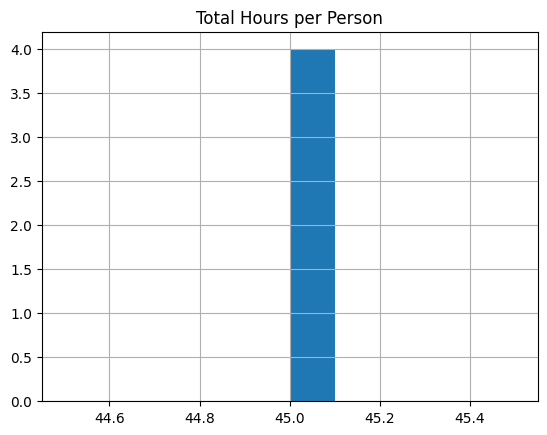

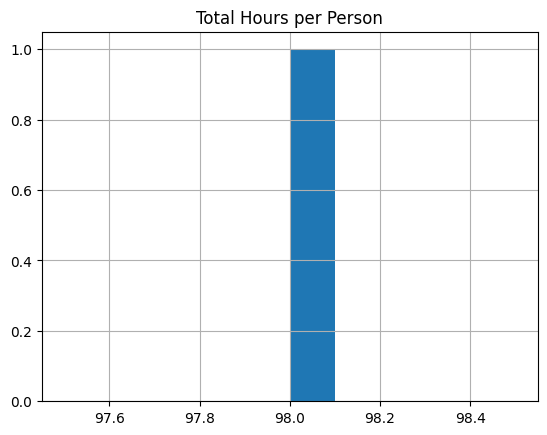

In [61]:
auburn_df=df.loc[df['Schools']=='Auburn University - College of Nursing - BSN',['Total Hours per Person']]
print(auburn_df)
auburn_df.hist()

augusta_df=df.loc[df['Schools']=='Augusta University (Athens Campus) - Nursing',['Total Hours per Person']]
print(augusta_df)
augusta_df.hist()

brenau_df=df.loc[df['Schools']=='Brenau University',['Total Hours per Person']]
print(brenau_df)
brenau_df.hist()

chamberlainatl_df=df.loc[df['Schools']=='Chamberlain College of Nursing - Atlanta',['Total Hours per Person']]
print(chamberlainatl_df)
chamberlainatl_df.hist()

chamberlainga_df=df.loc[df['Schools']=='Chamberlain College of Nursing - Georgia',['Total Hours per Person']]
print(chamberlainga_df)
chamberlainga_df.hist()

columbus_df=df.loc[df['Schools']=='Columbus State University - Nursing',['Total Hours per Person']]
print(columbus_df)
columbus_df.hist()

dalton_df=df.loc[df['Schools']=='Dalton State College - Nursing',['Total Hours per Person']]
print(dalton_df)
dalton_df.hist()